# Bias–Variance และ Learning Curves
งานนี้แบ่งเป็น 3 ส่วนตามโจทย์ รันทีละเซลล์จากบนลงล่างได้เลย

- **ส่วนที่ 1–2:** หา bias และ variance ด้วย *analytical* และ *simulation* ของ 3 แบบจำลอง
  (ค่าคงที่ `h=b`, เชิงเส้น `h=ax+b`, เชิงเส้นผ่านจุดกำเนิด `h=ax`)
  กับฟังก์ชันเป้าหมาย `sin(πx)` และ `x²` สุ่มข้อมูล 2 จุดจาก `U[-1,1]`
- **ส่วนที่ 3:** learning curves เปรียบเทียบ 3 แบบจำลอง + ทดลองใส่ noise

> ใช้ **normal equation** ในการสร้างแบบจำลอง (ไม่ใช้ gradient descent)

## 0) Import ไลบรารีและตั้งค่าตัวสุ่ม

In [ ]:
# numpy       : คำนวณเวกเตอร์/เมทริกซ์ และสุ่มตัวเลข
# matplotlib  : วาดกราฟ
# scipy.integrate : ใช้อินทิเกรตเชิงตัวเลข (analytical bias/variance)
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate

%matplotlib inline
# กำหนด seed ให้ผลการสุ่มซ้ำได้ทุกครั้งที่รัน
rng = np.random.default_rng(42)

## ส่วน A) TOOLKIT — ฟังก์ชันพื้นฐาน + normal equation
ตกลง convention ของเวกเตอร์พารามิเตอร์ `theta` ให้เหมือนกันทั้งไฟล์:
`theta[0] = b` (จุดตัดแกน / intercept), `theta[1:] = a` (ความชัน / สัมประสิทธิ์)

In [2]:
def linear_regression_predict(X, theta):
    """ทำนายค่า y_hat = X @ (ความชัน) + intercept"""
    return X @ theta[1:] + theta[0]

def compute_cost_linear(X, y, theta):
    """cost = ครึ่งหนึ่งของ MSE  (mean squared error / 2)"""
    p = linear_regression_predict(X, theta)   # ค่าที่ทำนายได้
    newY = p - y                              # ส่วนต่างจากค่าจริง
    m = X.shape[0]                            # จำนวนตัวอย่าง
    return (1 / (2 * m)) * np.sum(newY ** 2)

def compute_r2(y_true, y_pred):
    """ค่า R^2 ไว้ประเมินคุณภาพแบบจำลอง (ยิ่งใกล้ 1 ยิ่งดี)"""
    y_mean = np.mean(y_true)
    SSR = np.sum((y_true - y_pred) ** 2)      # ผลรวมกำลังสองของ residual
    SST = np.sum((y_true - y_mean) ** 2)      # ความแปรปรวนรวมของข้อมูล
    if SST == 0:
        return 1.0
    return 1 - (SSR / SST)

def normal_equation(X, y):
    """normal equation แบบมี intercept
       แปะคอลัมน์ 1 ไว้หน้า X แล้วแก้สมการ  theta = (Xa^T Xa)^(-1) Xa^T y
       ใช้ pinv (pseudo-inverse) เพื่อความเสถียรเมื่อเมทริกซ์เกือบเอกฐาน
       คืน theta = [b, a1, a2, ...]"""
    m = X.shape[0]
    Xaug = np.hstack((np.ones((m, 1)), X))    # เพิ่มคอลัมน์ค่าคงที่ 1 (สำหรับ b)
    theta = np.linalg.pinv(Xaug.T @ Xaug) @ Xaug.T @ y
    return theta

def normal_equation_origin(X, y):
    """normal equation แบบผ่านจุดกำเนิด (บังคับ b = 0 ไม่มี intercept)
       คืน theta = [0, a] ให้ convention ตรงกับตัวอื่น จะได้ใช้ predict ตัวเดียวกันได้"""
    theta_a = np.linalg.pinv(X.T @ X) @ X.T @ y
    return np.concatenate(([0.0], np.atleast_1d(theta_a)))

## ส่วน B) นิยาม 3 แบบจำลอง + 2 ฟังก์ชันเป้าหมาย
ทุกแบบจำลองรับ `(x, y)` เป็นข้อมูล 1 มิติ แล้วคืน `theta = [b, a]` เสมอ
(แบบจำลองไหนไม่มีพจน์นั้น ค่าจะเป็น 0 เอง)

In [3]:
def fit_const(x, y):
    # แบบจำลองค่าคงที่ h(x)=b : ใช้ feature ว่าง (m,0) เหลือแต่ intercept
    X0 = x.reshape(-1, 1)[:, :0]
    return normal_equation(X0, y)          # theta = [b]

def fit_linear(x, y):
    # แบบจำลองเชิงเส้น h(x)=a*x+b : feature = x
    X = x.reshape(-1, 1)
    return normal_equation(X, y)           # theta = [b, a]

def fit_origin(x, y):
    # แบบจำลองเชิงเส้นผ่านจุดกำเนิด h(x)=a*x : ไม่มี b
    X = x.reshape(-1, 1)
    return normal_equation_origin(X, y)    # theta = [0, a]

# รวมแบบจำลองไว้ใน dict เพื่อวนลูปเรียกใช้แบบเดียวกัน
MODELS = {"constant":   fit_const,
          "linear":     fit_linear,
          "lin-origin": fit_origin}

# ฟังก์ชันเป้าหมาย 2 แบบตามโจทย์
TARGETS = {"sin(pi*x)": lambda x: np.sin(np.pi * x),
           "x^2":       lambda x: x ** 2}

def predict_on_grid(theta, xs):
    """ทำนายค่าบน grid ของ x : theta[0]=b เสมอ, ถ้ามี theta[1] คือ a ไม่งั้นถือ a=0"""
    a = theta[1] if len(theta) > 1 else 0.0
    return a * xs + theta[0]

## ส่วน C) BIAS–VARIANCE  (ตอบส่วนที่ 1–2 ของโจทย์)

นิยามที่ใช้:
- `g_D(x)` = แบบจำลองที่ fit จากชุดข้อมูล D หนึ่งชุด
- `gbar(x) = E_D[g_D(x)]` = แบบจำลองเฉลี่ยเหนือชุดข้อมูลทั้งหมด
- `bias = E_x[(gbar(x) − f(x))²]`
- `variance = E_x[ E_D[(g_D(x) − gbar(x))²] ]`

### C.1 นิยามฟังก์ชัน simulation (Monte Carlo) และ analytical (อินทิเกรตตรง)

In [4]:
def simulate(f, fit, M=100_000):
    """วิธี SIMULATION: สุ่มชุดข้อมูล 2 จุด จำนวน M รอบ แล้วประมาณ bias, variance"""
    xs = np.linspace(-1, 1, 1001)          # grid สำหรับเฉลี่ยเหนือ x
    G = np.zeros((M, len(xs)))             # เก็บเส้นทำนายของทุกรอบ
    for m in range(M):
        x = rng.uniform(-1, 1, 2)          # สุ่มข้อมูล 2 จุดจาก U[-1,1]
        theta = fit(x, f(x))               # ไม่มี noise ในส่วนนี้
        G[m] = predict_on_grid(theta, xs)
    gbar = G.mean(axis=0)                   # แบบจำลองเฉลี่ย gbar(x)
    bias = np.mean((gbar - f(xs)) ** 2)     # เฉลี่ยกำลังสองของ (gbar - f) เหนือ x
    var  = np.mean(G.var(axis=0))           # var เหนือ D แล้วเฉลี่ยเหนือ x
    return bias, var, xs, gbar, G

def analytical(f, fit):
    """วิธี ANALYTICAL: ใช้สูตรค่าคาดหวังโดยตรง
       เฉลี่ย a, b เหนือ (x1,x2) ~ U[-1,1]^2  (ความหนาแน่นร่วม = 1/4)"""
    def ab(x1, x2):
        # fit จากข้อมูล 2 จุด แล้วแยกออกมาเป็น (a, b)
        theta = fit(np.array([x1, x2]), f(np.array([x1, x2])))
        a = theta[1] if len(theta) > 1 else 0.0
        return a, theta[0]

    def E(g):
        # ค่าคาดหวังของ g(a,b) = อินทิเกรต 2 ชั้นเหนือ (x1,x2) คูณความหนาแน่น 1/4
        v, _ = integrate.dblquad(lambda x2, x1: g(*ab(x1, x2)) * 0.25,
                                 -1, 1, -1, 1)
        return v

    # โมเมนต์ที่ต้องใช้: E[a], E[b], E[a^2], E[b^2], E[ab]
    Ea  = E(lambda a, b: a)
    Eb  = E(lambda a, b: b)
    Ea2 = E(lambda a, b: a * a)
    Eb2 = E(lambda a, b: b * b)
    Eab = E(lambda a, b: a * b)

    # gbar(x) = E[a]*x + E[b]  ->  bias = อินทิเกรต (gbar - f)^2 * (1/2) dx
    bias, _ = integrate.quad(
        lambda x: (Ea * x + Eb - f(x)) ** 2 * 0.5, -1, 1)
    # var(x) = E[g^2] - gbar^2 = (E[a^2]x^2 + 2E[ab]x + E[b^2]) - (E[a]x+E[b])^2
    var, _ = integrate.quad(
        lambda x: (Ea2 * x**2 + 2 * Eab * x + Eb2
                   - (Ea * x + Eb) ** 2) * 0.5, -1, 1)
    return bias, var

### C.2 รันทุกคู่ (ฟังก์ชันเป้าหมาย × แบบจำลอง) และวาดรูป
แต่ละกราฟแสดง: เส้น g_D ตัวอย่าง (สีเทา), แถบ gbar ± sd (ฟ้า), f(x) จริง (เขียว), gbar(x) (แดงประ)

> เซลล์นี้ตั้ง `M=100_000` อาจใช้เวลาหลายสิบวินาที ถ้าอยากเร็วปรับ `M` ให้น้อยลงได้

target     model       | bias(ana) bias(sim) |  var(ana)  var(sim) |    Eout
------------------------------------------------------------------------------
sin(pi*x)  constant    |    0.5000    0.4995 |    0.2500    0.2494 |  0.7500
sin(pi*x)  linear      |    0.2067    0.2063 |    1.6763    1.6641 |  1.8830
sin(pi*x)  lin-origin  |    0.2706    0.2732 |    0.2366    0.2380 |  0.5072
x^2        constant    |    0.0889    0.0892 |    0.0444    0.0444 |  0.1333
x^2        linear      |    0.2000    0.2011 |    0.3333    0.3340 |  0.5333
x^2        lin-origin  |    0.2000    0.2008 |    0.1149    0.1153 |  0.3149


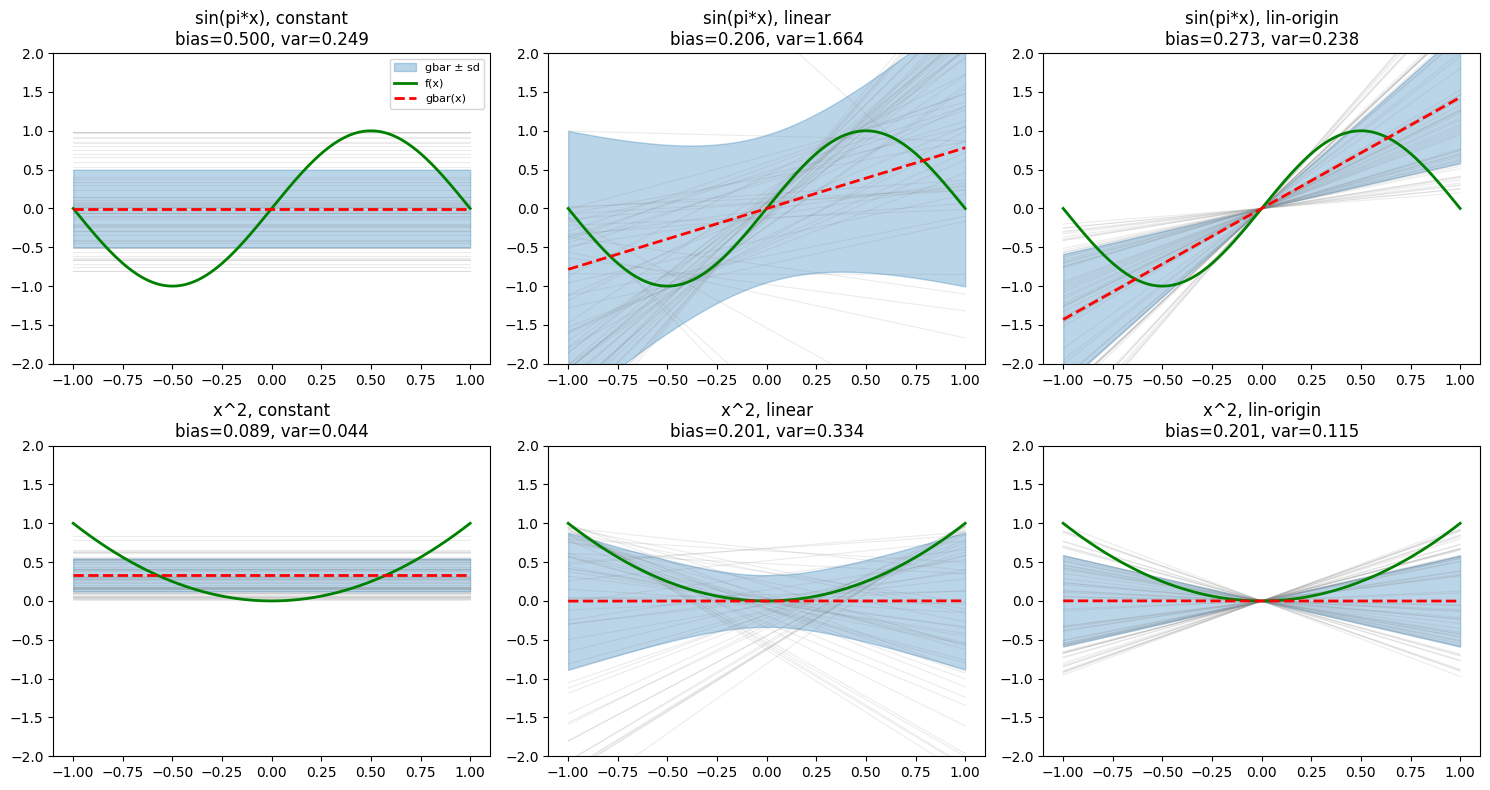

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# หัวตาราง
print(f"{'target':<10} {'model':<11} | {'bias(ana)':>9} {'bias(sim)':>9}"
      f" | {'var(ana)':>9} {'var(sim)':>9} | {'Eout':>7}")
print("-" * 78)

for i, (fname, f) in enumerate(TARGETS.items()):
    for j, (mname, fit) in enumerate(MODELS.items()):
        b_a, v_a = analytical(f, fit)            # ค่าจากสูตร
        b_s, v_s, xs, gbar, G = simulate(f, fit) # ค่าจากการจำลอง
        print(f"{fname:<10} {mname:<11} | {b_a:9.4f} {b_s:9.4f}"
              f" | {v_a:9.4f} {v_s:9.4f} | {b_a+v_a:7.4f}")

        ax = axes[i, j]
        for g in G[:60]:                          # เส้นตัวอย่าง 60 เส้นจาง ๆ
            ax.plot(xs, g, color="gray", alpha=0.15, lw=0.8)
        sd = G.std(axis=0)
        ax.fill_between(xs, gbar - sd, gbar + sd, color="tab:blue",
                        alpha=0.3, label="gbar ± sd")
        ax.plot(xs, f(xs), "g", lw=2, label="f(x)")     # ฟังก์ชันเป้าหมาย
        ax.plot(xs, gbar, "r--", lw=2, label="gbar(x)") # แบบจำลองเฉลี่ย
        ax.set_ylim(-2, 2)
        ax.set_title(f"{fname}, {mname}\nbias={b_s:.3f}, var={v_s:.3f}")
        if i == 0 and j == 0:
            ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("bias_variance.png", dpi=120)   # บันทึกรูป
plt.show()

## ส่วน D) LEARNING CURVES  (ตอบส่วนที่ 3 ของโจทย์)
เปรียบเทียบ 3 แบบจำลองว่าเมื่อเพิ่มจำนวนตัวอย่างฝึก N แล้ว error เปลี่ยนอย่างไร
และทดลองเพิ่มเติมด้วยการใส่สัญญาณรบกวน (noise ~ N(0, σ²))

### D.1 นิยามฟังก์ชัน learning curve
- `Ein`  = MSE บนชุดฝึก (เทียบกับ y ที่อาจมี noise)
- `Eout` = MSE เทียบ f จริง บน grid (คือค่าคาดหวังของ error เหนือ x จริง ๆ)

In [6]:
def _pad(theta):
    """ทำให้ theta ยาว 2 เสมอ ([b] -> [b, 0]) เพื่อให้ predict ใช้ได้"""
    return theta if len(theta) > 1 else np.array([theta[0], 0.0])

def learning_curve(f, fit, Ns, sigma=0.0, trials=3000):
    """คืน (Ein เฉลี่ย, Eout เฉลี่ย) ต่อแต่ละค่า N ใน Ns
       ทำซ้ำ trials รอบต่อ N เพื่อเฉลี่ยความผันผวนจากการสุ่ม"""
    xs = np.linspace(-1, 1, 400)               # grid สำหรับวัด Eout
    Ein, Eout = [], []
    for N in Ns:
        ein = eout = 0.0
        for _ in range(trials):
            x = rng.uniform(-1, 1, N)           # สุ่มชุดฝึก N จุด
            y = f(x) + sigma * rng.standard_normal(N)   # ใส่ noise ลงในเป้าหมาย
            theta = fit(x, y)
            X = x.reshape(-1, 1)
            ein  += 2 * compute_cost_linear(X, y, _pad(theta))   # = MSE บนชุดฝึก
            eout += np.mean((predict_on_grid(theta, xs) - f(xs)) ** 2)  # เทียบ f จริง
        Ein.append(ein / trials)
        Eout.append(eout / trials)
    return np.array(Ein), np.array(Eout)

### D.2 วาด learning curves (ไม่มี noise เทียบกับ มี noise)
เส้นทึบ = Eout, เส้นประ = Ein, เส้นจุด = ระดับ noise อ้างอิง σ²
เปลี่ยน `fname` เป็น `"x^2"` เพื่อดูอีกฟังก์ชันเป้าหมายได้

sigma=0.0  constant    Eout(N=2)=0.753  Eout(N=60)=0.507
sigma=0.0  linear      Eout(N=2)=1.873  Eout(N=60)=0.206
sigma=0.0  lin-origin  Eout(N=2)=0.510  Eout(N=60)=0.202
sigma=0.3  constant    Eout(N=2)=0.795  Eout(N=60)=0.509
sigma=0.3  linear      Eout(N=2)=2208.499  Eout(N=60)=0.208
sigma=0.3  lin-origin  Eout(N=2)=0.720  Eout(N=60)=0.204


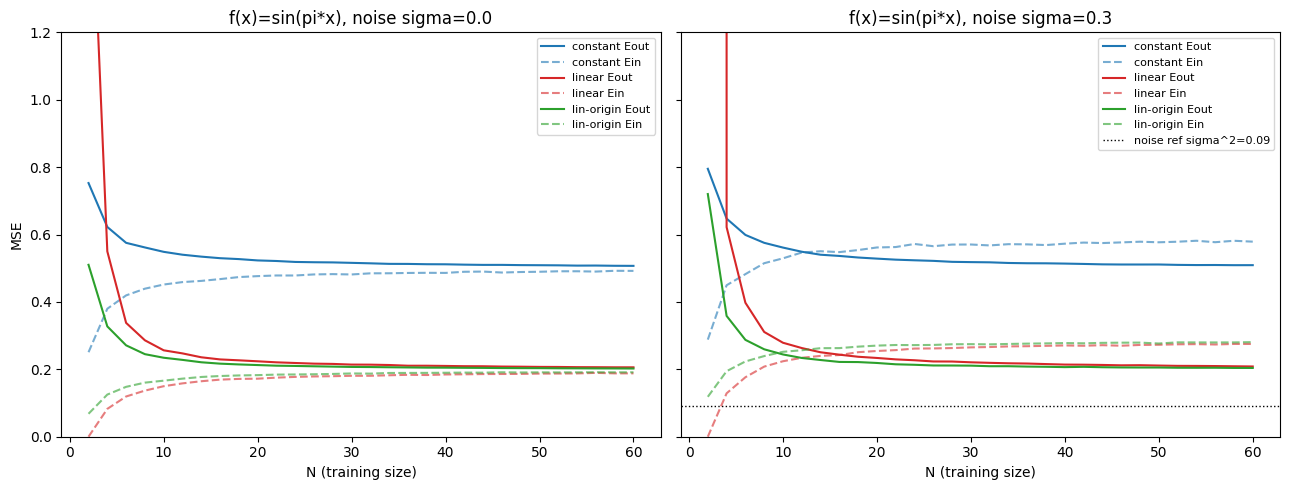

In [7]:
fname = "sin(pi*x)"        # เปลี่ยนเป็น "x^2" ได้
f = TARGETS[fname]
Ns = np.arange(2, 61, 2)   # จำนวนตัวอย่างฝึก 2,4,...,60
sigmas = [0.0, 0.3]        # ซ้าย = ไม่มี noise, ขวา = มี noise
colors = {"constant": "tab:blue", "linear": "tab:red", "lin-origin": "tab:green"}

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, sigma in zip(axes, sigmas):
    for name, fit in MODELS.items():
        Ein, Eout = learning_curve(f, fit, Ns, sigma)
        ax.plot(Ns, Eout, "-",  color=colors[name], label=f"{name} Eout")
        ax.plot(Ns, Ein, "--",  color=colors[name], alpha=0.6, label=f"{name} Ein")
        print(f"sigma={sigma}  {name:<10}  Eout(N=2)={Eout[0]:.3f}  Eout(N=60)={Eout[-1]:.3f}")
    if sigma > 0:
        # เส้นอ้างอิงระดับ noise (หมายเหตุ: Eout นี้วัดเทียบ f จริง จึงไม่จำเป็นต้องลู่เข้าหา sigma^2)
        ax.axhline(sigma**2, color="k", ls=":", lw=1, label=f"noise ref sigma^2={sigma**2:.2f}")
    ax.set_title(f"f(x)={fname}, noise sigma={sigma}")
    ax.set_xlabel("N (training size)")
    ax.set_ylim(0, 1.2)
    ax.legend(fontsize=8)
axes[0].set_ylabel("MSE")
plt.tight_layout()
plt.savefig("learning_curves.png", dpi=120)
plt.show()